<a href="https://colab.research.google.com/github/eshwar-7419/cads/blob/main/CARC_IDS_Phase2A_R_Corrected_Attack_Drift_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2A-R — Corrected Attack-Family & Drift Mapping

## Purpose

This notebook is a **correction of Phase 2A**. It does not train the continual-learning model yet.

The previous Phase-2A attack-family calculation accidentally included `Normal` when measuring attack-family composition. This notebook fixes that by calculating attack-family distributions **only among rows with `label == 1`**.

It also adds a stronger analysis of the evidence needed before constructing continual-learning tasks:

1. sequential class prevalence;
2. attack-family composition among attacks only;
3. first appearance / retention / disappearance;
4. corrected attack-family Jensen–Shannon divergence;
5. numeric feature drift;
6. class-conditional drift;
7. candidate adaptation boundaries;
8. an evidence-based recommendation for the Phase-2 continual-learning stream.

### Important terminology

A category first appearing in this dataset is called **newly observed within the experimental stream**.

It is **not** automatically called a novel real-world threat.

Likewise, a change in attack prevalence is not automatically called concept drift.

We distinguish:

- prior/class-prevalence shift: `P(Y)`;
- covariate/feature shift: `P(X)`;
- conditional/concept shift: `P(Y|X)`.


In [1]:
# 1. Install dependencies
!pip -q install datasets scipy pandas numpy matplotlib scikit-learn

print("Dependencies installed.")


Dependencies installed.


In [2]:
# 2. Imports

import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

BASE = Path("/content/carc_ids_phase2a_corrected")
RESULTS = BASE / "results"
FIGURES = BASE / "figures"

RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print(BASE)


/content/carc_ids_phase2a_corrected


## 3. Load the same dataset

Use the exact dataset/configuration from Phases 1 and 2A:

```python
lacg030175/UNSW-NB15
temporal
```

Only the training split is used to construct the experimental stream.

The final test set is kept outside the task-construction analysis.


In [3]:
# 3. Load dataset

ds = load_dataset(
    "lacg030175/UNSW-NB15",
    "temporal"
)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nTraining labels:")
display(train_df["label"].value_counts(dropna=False).sort_index().rename("count").to_frame())

print("\nAttack categories:")
display(train_df["attack_cat"].value_counts(dropna=False).rename("count").to_frame())


README.md:   0%|          | 0.00/5.32k [00:00<?, ?B/s]

temporal/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.7MB            

temporal/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

temporal/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.25MB            

temporal/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/82332 [00:00<?, ? examples/s]

Train: (175341, 44)
Test : (82332, 44)

Training labels:


,count
label,
0,56000
1,119341



Attack categories:


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


# 4. Create the same ten sequential segments

We retain the same segmentation used in Phase 1B/2A so that the corrected analysis is directly comparable with the earlier outputs.

These are **segments**, not yet final continual-learning tasks.


In [4]:
N_SEGMENTS = 10

segment_indices = np.array_split(np.arange(len(train_df)), N_SEGMENTS)

segments = {
    sid: train_df.iloc[idx].copy()
    for sid, idx in enumerate(segment_indices, start=1)
}

segment_rows = []

for sid, df in segments.items():
    n = len(df)
    benign = int((df["label"] == 0).sum())
    attack = int((df["label"] == 1).sum())

    segment_rows.append({
        "segment": sid,
        "rows": n,
        "benign": benign,
        "attack": attack,
        "benign_pct": benign/n,
        "attack_pct": attack/n
    })

segment_summary = pd.DataFrame(segment_rows)

display(segment_summary.round(4))
segment_summary.to_csv(RESULTS/"segment_class_distribution.csv", index=False)


,segment,rows,benign,attack,benign_pct,attack_pct
0,1,17535,17535,0,1.0000,0.0000
1,2,17534,17534,0,1.0000,0.0000
2,3,17534,12842,4692,0.7324,0.2676
3,4,17534,799,16735,0.0456,0.9544
4,5,17534,2438,15096,0.1390,0.8610
5,6,17534,2168,15366,0.1236,0.8764
6,7,17534,2684,14850,0.1531,0.8469
7,8,17534,0,17534,0.0000,1.0000
8,9,17534,0,17534,0.0000,1.0000
9,10,17534,0,17534,0.0000,1.0000


# 5. Correct attack-family calculation

This is the critical correction.

We first filter:

```python
label == 1
```

and **only then** calculate `attack_cat` proportions.

Therefore `Normal` cannot contaminate the attack-family distribution.

If an attack row has a missing category, it is retained as `Unknown` and reported explicitly.


In [5]:
# 5. Attack-only category counts

attack_only_segments = {}

for sid, df in segments.items():
    attack_df = df[df["label"] == 1].copy()

    attack_df["attack_cat_norm"] = (
        attack_df["attack_cat"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

    attack_only_segments[sid] = attack_df

all_attack_categories = sorted(
    set().union(*[
        set(df["attack_cat_norm"].unique())
        for df in attack_only_segments.values()
        if len(df)
    ])
)

attack_counts = pd.DataFrame(
    0,
    index=range(1, N_SEGMENTS+1),
    columns=all_attack_categories
)

for sid, df in attack_only_segments.items():
    counts = df["attack_cat_norm"].value_counts()
    for cat, count in counts.items():
        attack_counts.loc[sid, cat] = int(count)

print("Corrected attack-only category counts:")
display(attack_counts)


Corrected attack-only category counts:


,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,227,274,379,1436,1892,0,412,68,4
4,396,182,2341,7549,3799,0,2200,239,29
5,425,349,2487,6505,3088,0,2014,202,26
6,330,325,2428,6445,3393,0,2189,228,28
7,281,287,2247,5409,2431,2376,1626,173,20
8,150,155,1095,2523,1401,11241,863,94,12
9,105,101,770,1870,1105,12890,624,63,6
10,86,73,517,1656,1075,13493,563,66,5


In [6]:
# 6. Attack-only category proportions

attack_props = attack_counts.astype(float)

for sid in attack_props.index:
    total = attack_props.loc[sid].sum()
    if total > 0:
        attack_props.loc[sid] /= total

print("Corrected attack-family proportions:")
display(attack_props.round(6))

attack_counts.to_csv(RESULTS/"corrected_attack_category_counts_by_segment.csv")
attack_props.to_csv(RESULTS/"corrected_attack_category_proportions_by_segment.csv")


Corrected attack-family proportions:


,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.048380,0.058397,0.080776,0.306053,0.403240,0.000000,0.087809,0.014493,0.000853
4,0.023663,0.010875,0.139886,0.451091,0.227009,0.000000,0.131461,0.014281,0.001733
5,0.028153,0.023119,0.164746,0.430909,0.204557,0.000000,0.133413,0.013381,0.001722
6,0.021476,0.021151,0.158011,0.419433,0.220812,0.000000,0.142457,0.014838,0.001822
7,0.018923,0.019327,0.151313,0.364242,0.163704,0.160000,0.109495,0.011650,0.001347
8,0.008555,0.008840,0.062450,0.143892,0.079902,0.641097,0.049219,0.005361,0.000684
9,0.005988,0.005760,0.043915,0.106650,0.063020,0.735143,0.035588,0.003593,0.000342
10,0.004905,0.004163,0.029486,0.094445,0.061309,0.769533,0.032109,0.003764,0.000285


## Sanity check

For every segment containing attacks:

\[
\sum_c P(c | attack, segment)=1
\]

There must be no `Normal` category in this table.


In [7]:
# 7. Sanity checks

assert "Normal" not in attack_props.columns, (
    "ERROR: Normal still appears in attack-family distribution."
)

for sid in attack_props.index:
    if attack_counts.loc[sid].sum() > 0:
        total = attack_props.loc[sid].sum()
        assert np.isclose(total, 1.0), (
            f"Segment {sid} attack proportions do not sum to 1: {total}"
        )

print("PASS: attack-family distributions contain only attack-labelled rows.")
print("PASS: each non-empty attack distribution sums to 1.")


PASS: attack-family distributions contain only attack-labelled rows.
PASS: each non-empty attack distribution sums to 1.


In [8]:
# 8. Attack-family lifecycle

lifecycle_rows = []

for cat in attack_props.columns:
    present = [
        sid for sid in attack_props.index
        if attack_counts.loc[sid, cat] > 0
    ]

    if present:
        lifecycle_rows.append({
            "attack_category": cat,
            "first_segment": min(present),
            "last_segment": max(present),
            "segments_present": len(present)
        })

lifecycle = pd.DataFrame(lifecycle_rows).sort_values(
    ["first_segment", "attack_category"]
).reset_index(drop=True)

display(lifecycle)

lifecycle.to_csv(RESULTS/"corrected_attack_category_lifecycle.csv", index=False)


,attack_category,first_segment,last_segment,segments_present
0,Analysis,3,10,8
1,Backdoor,3,10,8
2,DoS,3,10,8
3,Exploits,3,10,8
4,Fuzzers,3,10,8
5,Reconnaissance,3,10,8
6,Shellcode,3,10,8
7,Worms,3,10,8
8,Generic,7,10,4


In [9]:
# 9. Adjacent attack-family transitions

transition_rows = []

for sid in range(2, N_SEGMENTS+1):
    prev = {
        cat for cat in attack_props.columns
        if attack_counts.loc[sid-1, cat] > 0
    }

    curr = {
        cat for cat in attack_props.columns
        if attack_counts.loc[sid, cat] > 0
    }

    transition_rows.append({
        "from_segment": sid-1,
        "to_segment": sid,
        "new_categories": ", ".join(sorted(curr-prev)),
        "retained_categories": ", ".join(sorted(curr & prev)),
        "disappeared_categories": ", ".join(sorted(prev-curr)),
        "n_new": len(curr-prev),
        "n_retained": len(curr & prev),
        "n_disappeared": len(prev-curr)
    })

transitions = pd.DataFrame(transition_rows)

display(transitions)

transitions.to_csv(
    RESULTS/"corrected_attack_category_transitions.csv",
    index=False
)


,from_segment,to_segment,new_categories,retained_categories,disappeared_categories,n_new,n_retained,n_disappeared
0,1,2,,,,0,0,0
1,2,3,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Re...",,,8,0,0
2,3,4,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Re...",,0,8,0
3,4,5,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Re...",,0,8,0
4,5,6,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Re...",,0,8,0
5,6,7,Generic,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Re...",,1,8,0
6,7,8,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge...",,0,9,0
7,8,9,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge...",,0,9,0
8,9,10,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge...",,0,9,0


# 10. Corrected attack-family Jensen–Shannon divergence

We compare:

\[
P(attack\ category | segment)
\]

between adjacent segments.

If either adjacent segment contains no attacks, the attack-family divergence is marked `NaN` rather than assigning an artificial zero.


In [10]:
# 10. Correct JS divergence

def js_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if p.sum() == 0 or q.sum() == 0:
        return np.nan

    p = p / p.sum()
    q = q / q.sum()

    return float(jensenshannon(p, q, base=2) ** 2)

attack_js_rows = []

for sid in range(2, N_SEGMENTS+1):
    p = attack_props.loc[sid-1].to_numpy()
    q = attack_props.loc[sid].to_numpy()

    attack_js_rows.append({
        "from_segment": sid-1,
        "to_segment": sid,
        "attack_category_js_divergence": js_divergence(p, q)
    })

attack_js = pd.DataFrame(attack_js_rows)

display(attack_js.round(6))

attack_js.to_csv(
    RESULTS/"corrected_attack_category_js_drift.csv",
    index=False
)


,from_segment,to_segment,attack_category_js_divergence
0,1,2,NaN
1,2,3,NaN
2,3,4,0.053181
3,4,5,0.003104
4,5,6,0.000822
5,6,7,0.086338
6,7,8,0.183880
7,8,9,0.007578
8,9,10,0.001789


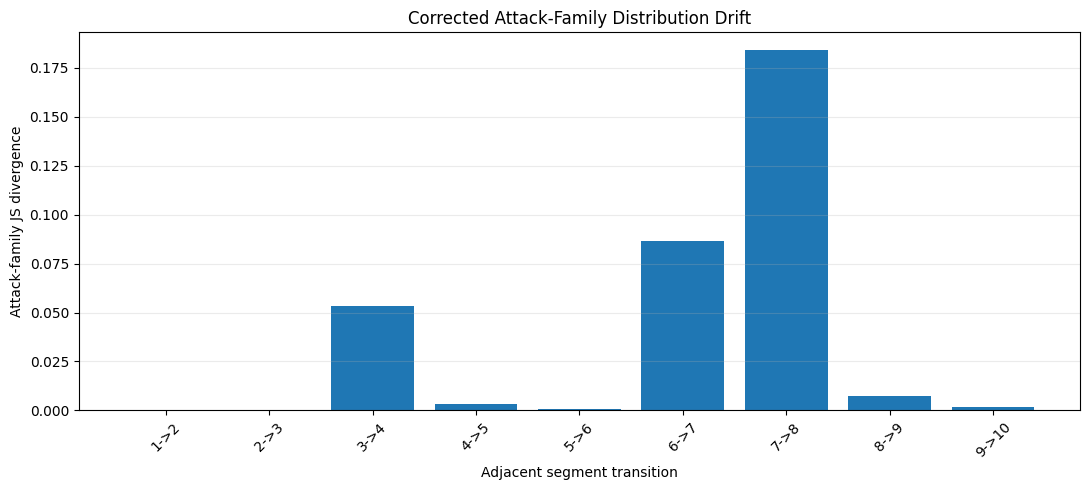

In [11]:
# 11. Plot corrected attack-family drift

fig, ax = plt.subplots(figsize=(11,5))

labels = [
    f"{r.from_segment}->{r.to_segment}"
    for r in attack_js.itertuples()
]

ax.bar(labels, attack_js["attack_category_js_divergence"].fillna(0))
ax.set_xlabel("Adjacent segment transition")
ax.set_ylabel("Attack-family JS divergence")
ax.set_title("Corrected Attack-Family Distribution Drift")
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES/"corrected_attack_family_js.png", dpi=160)
plt.show()


# 12. Numeric feature drift

We retain the Phase-2A feature-drift methodology but make the interpretation explicit.

We measure adjacent-segment changes using:

- histogram-based Jensen–Shannon divergence;
- normalized Wasserstein distance.

These are **distribution-shift indicators**.

They do not, by themselves, prove concept drift.


In [12]:
# 12. Select numeric features

DROP = {
    "label", "attack_cat", "id", "ID", "index"
}

numeric_features = [
    c for c in train_df.columns
    if c not in DROP
    and pd.api.types.is_numeric_dtype(train_df[c])
    and train_df[c].nunique(dropna=True) >= 5
]

print("Numeric features used:", len(numeric_features))
print(numeric_features)


Numeric features used: 36
['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'Dintpkt', 'djit', 'dload', 'dloss', 'dmeansz', 'Dpkts', 'dtcpb', 'dttl', 'dur', 'dwin', 'rate', 'response_body_len', 'sbytes', 'Sintpkt', 'Sjit', 'sload', 'sloss', 'smeansz', 'Spkts', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


In [13]:
# 13. Numeric drift functions

def numeric_js(p, q, bins=20):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = p[np.isfinite(p)]
    q = q[np.isfinite(q)]

    if len(p) == 0 or len(q) == 0:
        return np.nan

    combined = np.concatenate([p, q])
    lo, hi = np.percentile(combined, [1, 99])

    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return 0.0

    p = np.clip(p, lo, hi)
    q = np.clip(q, lo, hi)

    hp, edges = np.histogram(p, bins=bins, range=(lo, hi))
    hq, _ = np.histogram(q, bins=edges)

    hp = hp.astype(float) + 1e-12
    hq = hq.astype(float) + 1e-12

    hp /= hp.sum()
    hq /= hq.sum()

    return float(jensenshannon(hp, hq, base=2) ** 2)

def normalized_wasserstein(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = p[np.isfinite(p)]
    q = q[np.isfinite(q)]

    if len(p) == 0 or len(q) == 0:
        return np.nan

    combined = np.concatenate([p, q])
    lo, hi = np.percentile(combined, [1, 99])

    if hi <= lo:
        return 0.0

    p = np.clip(p, lo, hi)
    q = np.clip(q, lo, hi)

    return float(
        wasserstein_distance(p, q) / (hi-lo+1e-12)
    )


In [14]:
# 14. Feature drift across adjacent segments

feature_rows = []

for sid in range(2, N_SEGMENTS+1):
    prev = segments[sid-1]
    curr = segments[sid]

    for feature in numeric_features:
        p = pd.to_numeric(prev[feature], errors="coerce").to_numpy()
        q = pd.to_numeric(curr[feature], errors="coerce").to_numpy()

        feature_rows.append({
            "from_segment": sid-1,
            "to_segment": sid,
            "feature": feature,
            "js_divergence": numeric_js(p, q),
            "wasserstein_normalized": normalized_wasserstein(p, q)
        })

feature_drift = pd.DataFrame(feature_rows)

display(feature_drift.head(20))

feature_drift.to_csv(
    RESULTS/"corrected_numeric_feature_drift.csv",
    index=False
)


,from_segment,to_segment,feature,js_divergence,wasserstein_normalized
0,1,2,ackdat,0.003439,0.014025
1,1,2,ct_dst_ltm,0.028844,0.059048
2,1,2,ct_dst_sport_ltm,0.000180,0.004618
3,1,2,ct_dst_src_ltm,0.015553,0.039822
4,1,2,ct_flw_http_mthd,0.000048,0.004842
5,1,2,ct_src_dport_ltm,0.061678,0.076003
6,1,2,ct_src_ltm,0.045925,0.070418
7,1,2,ct_srv_dst,0.013944,0.036913
8,1,2,ct_srv_src,0.014460,0.036273
9,1,2,ct_state_ttl,0.001178,0.011861


In [15]:
# 15. Feature drift transition summary

feature_summary = (
    feature_drift
    .groupby(["from_segment","to_segment"])
    .agg(
        mean_js=("js_divergence","mean"),
        median_js=("js_divergence","median"),
        max_js=("js_divergence","max"),
        mean_wasserstein=("wasserstein_normalized","mean"),
        median_wasserstein=("wasserstein_normalized","median"),
        max_wasserstein=("wasserstein_normalized","max")
    )
    .reset_index()
)

display(feature_summary.round(6))

feature_summary.to_csv(
    RESULTS/"corrected_feature_drift_transition_summary.csv",
    index=False
)


,from_segment,to_segment,mean_js,median_js,max_js,mean_wasserstein,median_wasserstein,max_wasserstein
0,1,2,0.016548,0.007222,0.095863,0.024831,0.017887,0.076003
1,2,3,0.100796,0.061744,0.419570,0.090176,0.058733,0.498202
2,3,4,0.038014,0.018883,0.189282,0.046452,0.032998,0.226210
3,4,5,0.006005,0.001867,0.029311,0.010557,0.004954,0.036107
4,5,6,0.003773,0.002717,0.017439,0.015076,0.010973,0.057077
5,6,7,0.028721,0.024253,0.099486,0.059627,0.053146,0.216197
6,7,8,0.056211,0.024896,0.191192,0.105347,0.077264,0.347074
7,8,9,0.004312,0.002723,0.020763,0.021302,0.012977,0.061312
8,9,10,0.001983,0.000862,0.008062,0.007750,0.005889,0.033988


# 16. Class-conditional drift

We separately examine:

- benign traffic: `P(X | Y=0)`;
- attack traffic: `P(X | Y=1)`.

This is crucial.

A large change in attack prevalence is not enough to claim concept drift.

A stronger adaptation signal occurs when the attack-conditioned feature distribution changes.


In [16]:
# 16. Class-conditional feature drift

conditional_rows = []

for sid in range(2, N_SEGMENTS+1):
    prev = segments[sid-1]
    curr = segments[sid]

    for y_value, name in [(0,"benign"), (1,"attack")]:
        prev_c = prev[prev["label"] == y_value]
        curr_c = curr[curr["label"] == y_value]

        if len(prev_c) < 20 or len(curr_c) < 20:
            conditional_rows.append({
                "from_segment": sid-1,
                "to_segment": sid,
                "class": name,
                "n_prev": len(prev_c),
                "n_curr": len(curr_c),
                "mean_js": np.nan,
                "median_js": np.nan,
                "coverage": 0.0
            })
            continue

        values = []

        for feature in numeric_features:
            p = pd.to_numeric(prev_c[feature], errors="coerce").to_numpy()
            q = pd.to_numeric(curr_c[feature], errors="coerce").to_numpy()

            value = numeric_js(p, q)

            if np.isfinite(value):
                values.append(value)

        conditional_rows.append({
            "from_segment": sid-1,
            "to_segment": sid,
            "class": name,
            "n_prev": len(prev_c),
            "n_curr": len(curr_c),
            "mean_js": np.mean(values) if values else np.nan,
            "median_js": np.median(values) if values else np.nan,
            "coverage": len(values)/len(numeric_features)
        })

conditional = pd.DataFrame(conditional_rows)

display(conditional.round(6))

conditional.to_csv(
    RESULTS/"corrected_class_conditional_drift.csv",
    index=False
)


,from_segment,to_segment,class,n_prev,n_curr,mean_js,median_js,coverage
0,1,2,benign,17535,17534,0.016548,0.007222,1.0
1,1,2,attack,0,0,NaN,NaN,0.0
2,2,3,benign,17534,12842,0.081697,0.050644,1.0
3,2,3,attack,0,4692,NaN,NaN,0.0
4,3,4,benign,12842,799,0.089826,0.074795,1.0
5,3,4,attack,4692,16735,0.005366,0.003812,1.0
6,4,5,benign,799,2438,0.069213,0.041930,1.0
7,4,5,attack,16735,15096,0.005979,0.000699,1.0
8,5,6,benign,2438,2168,0.042131,0.021820,1.0
9,5,6,attack,15096,15366,0.003574,0.001690,1.0


# 17. Candidate boundary evidence

We now combine the corrected attack-family evidence with feature/conditional evidence.

The score is deliberately transparent and **diagnostic only**.

A candidate boundary can be supported by:

- attack-prevalence change;
- attack-family distribution change;
- feature distribution change;
- new attack family within the stream.

The score is not a validated drift detector and must not be presented as one.


In [17]:
# 17. Candidate boundary table

candidate = segment_summary.copy()

candidate["attack_prevalence_abs_change"] = (
    candidate["attack_pct"] -
    candidate["attack_pct"].shift(1)
).abs()

candidate = candidate.merge(
    attack_js.rename(columns={"to_segment":"segment"}),
    on="segment",
    how="left"
)

candidate = candidate.merge(
    feature_summary.rename(columns={"to_segment":"segment"}),
    on="segment",
    how="left"
)

candidate = candidate.merge(
    transitions[[
        "to_segment","n_new","n_retained","n_disappeared"
    ]].rename(columns={"to_segment":"segment"}),
    on="segment",
    how="left"
)

candidate[["n_new","n_retained","n_disappeared"]] = (
    candidate[["n_new","n_retained","n_disappeared"]]
    .fillna(0)
)

candidate["boundary_evidence_score"] = (
    (candidate["attack_prevalence_abs_change"] >= 0.25).astype(int)
    + (candidate["attack_category_js_divergence"] >= 0.10).astype(int)
    + (candidate["mean_js"] >= 0.05).astype(int)
    + (candidate["n_new"] > 0).astype(int)
)

display(candidate[[
    "segment",
    "attack_pct",
    "attack_prevalence_abs_change",
    "attack_category_js_divergence",
    "mean_js",
    "median_js",
    "n_new",
    "n_retained",
    "n_disappeared",
    "boundary_evidence_score"
]].round(6))

candidate.to_csv(
    RESULTS/"corrected_candidate_boundary_evidence.csv",
    index=False
)


,segment,attack_pct,attack_prevalence_abs_change,attack_category_js_divergence,mean_js,median_js,n_new,n_retained,n_disappeared,boundary_evidence_score
0,1,0.000000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
1,2,0.000000,0.000000,NaN,0.016548,0.007222,0.0,0.0,0.0,0
2,3,0.267594,0.267594,NaN,0.100796,0.061744,8.0,0.0,0.0,3
3,4,0.954431,0.686837,0.053181,0.038014,0.018883,0.0,8.0,0.0,1
4,5,0.860956,0.093476,0.003104,0.006005,0.001867,0.0,8.0,0.0,0
5,6,0.876355,0.015399,0.000822,0.003773,0.002717,0.0,8.0,0.0,0
6,7,0.846926,0.029429,0.086338,0.028721,0.024253,1.0,8.0,0.0,1
7,8,1.000000,0.153074,0.183880,0.056211,0.024896,0.0,9.0,0.0,2
8,9,1.000000,0.000000,0.007578,0.004312,0.002723,0.0,9.0,0.0,0
9,10,1.000000,0.000000,0.001789,0.001983,0.000862,0.0,9.0,0.0,0


# 18. Build a conservative candidate stream

We do not use every segment as a separate task.

Instead, this notebook proposes **candidate experience groups** only for inspection.

The grouping is deliberately conservative:

- Segment 1–2: benign pre-attack regime;
- Segment 3: first observed attack regime;
- Segment 4–6: mixed/high-attack regime;
- Segment 7: attack-family transition regime;
- Segment 8: Generic-dominant regime;
- Segment 9–10: stable late regime.

These are **candidate groups**, not yet the final benchmark.

The final task definition should be based on the corrected metrics and should preserve enough samples from each regime for training/evaluation.


In [18]:
# 18. Candidate experience grouping

candidate_groups = {
    "E0_pre_attack": [1, 2],
    "E1_first_attack": [3],
    "E2_mixed_high_attack": [4, 5, 6],
    "E3_attack_transition": [7],
    "E4_generic_dominant": [8],
    "E5_stable_late": [9, 10]
}

rows = []

for exp, sids in candidate_groups.items():
    subset = pd.concat([segments[s] for s in sids], ignore_index=True)

    rows.append({
        "experience": exp,
        "segments": ",".join(map(str,sids)),
        "rows": len(subset),
        "benign": int((subset.label==0).sum()),
        "attack": int((subset.label==1).sum()),
        "attack_pct": float(subset.label.mean()),
        "attack_categories": int(
            subset.loc[subset.label==1, "attack_cat"]
            .nunique()
        )
    })

candidate_experiences = pd.DataFrame(rows)

display(candidate_experiences)

candidate_experiences.to_csv(
    RESULTS/"candidate_experience_groups.csv",
    index=False
)


,experience,segments,rows,benign,attack,attack_pct,attack_categories
0,E0_pre_attack,"1,2",35069,35069,0,0.000000,0
1,E1_first_attack,3,17534,12842,4692,0.267594,8
2,E2_mixed_high_attack,"4,5,6",52602,5405,47197,0.897247,8
3,E3_attack_transition,7,17534,2684,14850,0.846926,9
4,E4_generic_dominant,8,17534,0,17534,1.000000,9
5,E5_stable_late,"9,10",35068,0,35068,1.000000,9


# 19. Automatic interpretation flags

These flags are deliberately conservative.

They do not claim that a transition is "concept drift".

They classify the available evidence into:

- `prior_shift_dominant`;
- `attack_family_shift`;
- `feature_shift`;
- `mixed_shift`;
- `insufficient_attack_evidence`.

This is intended to prevent us from building a continual learner around unsupported assumptions.


In [19]:
# 19. Evidence classification

# Attack conditional drift lookup
attack_cond = conditional[
    conditional["class"]=="attack"
][[
    "to_segment","mean_js"
]].rename(columns={"mean_js":"attack_conditional_mean_js"})

benign_cond = conditional[
    conditional["class"]=="benign"
][[
    "to_segment","mean_js"
]].rename(columns={"mean_js":"benign_conditional_mean_js"})

evidence = candidate.merge(
    attack_cond.rename(columns={"to_segment":"segment"}),
    on="segment",
    how="left"
).merge(
    benign_cond.rename(columns={"to_segment":"segment"}),
    on="segment",
    how="left"
)

def classify(row):
    if pd.isna(row["attack_category_js_divergence"]):
        return "insufficient_attack_evidence"

    family = row["attack_category_js_divergence"] >= 0.10
    attack_cond_shift = (
        pd.notna(row["attack_conditional_mean_js"])
        and row["attack_conditional_mean_js"] >= 0.05
    )
    feature = pd.notna(row["mean_js"]) and row["mean_js"] >= 0.05
    prior = row["attack_prevalence_abs_change"] >= 0.25

    if family or attack_cond_shift:
        if feature or prior:
            return "mixed_attack_distribution_shift"
        return "attack_family_or_conditional_shift"

    if feature or prior:
        return "prior_or_covariate_shift"

    return "low_evidence_shift"

evidence["evidence_class"] = evidence.apply(classify, axis=1)

display(evidence[[
    "segment",
    "attack_pct",
    "attack_prevalence_abs_change",
    "attack_category_js_divergence",
    "attack_conditional_mean_js",
    "benign_conditional_mean_js",
    "mean_js",
    "evidence_class"
]].round(6))

evidence.to_csv(
    RESULTS/"corrected_drift_evidence_classification.csv",
    index=False
)


,segment,attack_pct,attack_prevalence_abs_change,attack_category_js_divergence,attack_conditional_mean_js,benign_conditional_mean_js,mean_js,evidence_class
0,1,0.000000,NaN,NaN,NaN,NaN,NaN,insufficient_attack_evidence
1,2,0.000000,0.000000,NaN,NaN,0.016548,0.016548,insufficient_attack_evidence
2,3,0.267594,0.267594,NaN,NaN,0.081697,0.100796,insufficient_attack_evidence
3,4,0.954431,0.686837,0.053181,0.005366,0.089826,0.038014,prior_or_covariate_shift
4,5,0.860956,0.093476,0.003104,0.005979,0.069213,0.006005,low_evidence_shift
5,6,0.876355,0.015399,0.000822,0.003574,0.042131,0.003773,low_evidence_shift
6,7,0.846926,0.029429,0.086338,0.020851,0.284968,0.028721,low_evidence_shift
7,8,1.000000,0.153074,0.183880,0.053675,NaN,0.056211,mixed_attack_distribution_shift
8,9,1.000000,0.000000,0.007578,0.004312,NaN,0.004312,low_evidence_shift
9,10,1.000000,0.000000,0.001789,0.001983,NaN,0.001983,low_evidence_shift


# 20. Final Phase-2A-R decision logic

Do not proceed by assuming that all ten segments represent separate tasks.

The corrected evidence should determine whether we use:

### Minimal stream
A small number of meaningful experiences.

or

### More granular stream
Additional experiences if the category/feature evidence justifies them.

The final test set remains untouched.

### The proposed research design should favor fewer, defensible adaptation events over many artificial ones.


In [20]:
# 20. Produce a final machine-readable summary

summary = {
    "dataset": "lacg030175/UNSW-NB15",
    "config": "temporal",
    "n_training_segments": N_SEGMENTS,
    "attack_family_calculation": "label == 1 only; Normal excluded by construction",
    "final_test_used_for_task_construction": False,
    "candidate_experiences": candidate_groups,
    "metrics": {
        "attack_family_drift": "Jensen-Shannon divergence",
        "feature_drift": [
            "histogram Jensen-Shannon divergence",
            "normalized Wasserstein distance"
        ],
        "conditional_drift": "mean/median feature JS for benign and attack classes"
    },
    "interpretation_warning": (
        "Observed distribution shifts are not automatically equivalent to "
        "real-world concept drift or newly emerging threats."
    )
}

with open(RESULTS/"phase2a_corrected_protocol.json","w") as f:
    json.dump(summary, f, indent=2)

bundle = shutil.make_archive(
    str(BASE/"phase2a_corrected_artifacts"),
    "zip",
    root_dir=BASE
)

print("Created:", bundle)
print("\nOutputs:")
for p in sorted(RESULTS.glob("*")):
    print(" -", p)


Created: /content/carc_ids_phase2a_corrected/phase2a_corrected_artifacts.zip

Outputs:
 - /content/carc_ids_phase2a_corrected/results/candidate_experience_groups.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_attack_category_counts_by_segment.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_attack_category_js_drift.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_attack_category_lifecycle.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_attack_category_proportions_by_segment.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_attack_category_transitions.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_candidate_boundary_evidence.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_class_conditional_drift.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_drift_evidence_classification.csv
 - /content/carc_ids_phase2a_corrected/results/corrected_feature_drift_transition_summary.csv
 - /content/carc_i

# 21. What to send back

After running the notebook, send these files:

1. `corrected_attack_category_proportions_by_segment.csv`
2. `corrected_attack_category_transitions.csv`
3. `corrected_attack_category_js_drift.csv`
4. `corrected_class_conditional_drift.csv`
5. `corrected_candidate_boundary_evidence.csv`
6. `corrected_drift_evidence_classification.csv`
7. `candidate_experience_groups.csv`

These are sufficient to make the final Phase-2 task decision.

## Then we move to Phase 2B

The next experiment will compare:

1. Static LightGBM
2. Naive sequential fine-tuning/update
3. Replay
4. EWC
5. Proposed resource-aware adaptation

with measurements for:

- new-regime detection;
- retained-regime performance;
- forgetting;
- FPR;
- update frequency;
- training time;
- memory;
- adaptation utility.

The IPS response layer and local LLM should be added **after** the detection/adaptation benchmark is established.
